# The hypoexponential distribution to describe the inter-arrival time
If two or more exponential distributions are summed (convolution of probablitiy distributions) and their rate parameters are different, the resulting distribution is the hypoexponential distribution. 

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#user = r"\SagixOffice"  # HomeOffice
user = r"\vie43sq"
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")
import src.distributions as d
import src.fluorophore_systems as fs

In [3]:
rng = np.random.default_rng(100)

a, b, c = 4, 10, 16.7

exp1 = rng.exponential(1/a, size=1000000)
exp2 = rng.exponential(1/b, size=1000000)
exp3 = rng.exponential(1/c, size=1000000)

hypo_2_parameters = exp2 + exp3
hypo_3_parameters = exp1 + exp2 + exp3

## The two-parameter case

In [7]:
cdf_2_parameters = d.hypoexponential_distribution_two_parameters_cdf(b, c, np.linspace(0, 1, 200))
pdf_2_parameters = d.hypoexponential_distribution_two_parameters_pdf(b, c, np.linspace(0, 1, 200))

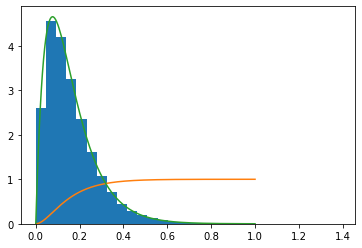

In [4]:
plt.hist(hypo_2_parameters, density=True, bins=30)
plt.plot(np.linspace(0, 1, 200), cdf_2_parameters)
plt.plot(np.linspace(0, 1, 200), pdf_2_parameters)

In [25]:
print(f'The observed probability of values below {np.linspace(0, 1, 200)[50]:.4f} is ' +
      f'{np.where(hypo_2_parameters<0.2512)[0].size / hypo_2_parameters.size :.2f}')
print(f'With the CDF, the probability calculated is {cdf_2_parameters[50]:.2f}')

The observed probability of values below 0.2513 is 0.82
With the CDF, the probability calculated is 0.82


---

## The three-parameter case

In [14]:
cdf_3_parameters = d.hypoexponential_distribution_three_parameters_cdf(a, b, c, np.linspace(0, 2, 200))
pdf_3_parameters = d.hypoexponential_distribution_three_parameters_pdf(a, b, c, np.linspace(0, 2, 200))

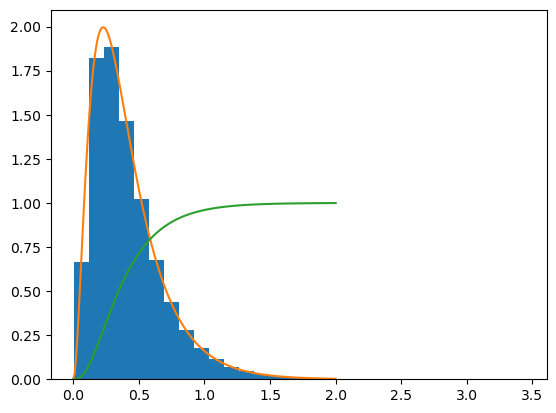

In [15]:
plt.hist(hypo_3_parameters, density=True, bins=30)
plt.plot(np.linspace(0, 2, 200), pdf_3_parameters)
plt.plot(np.linspace(0, 2, 200), cdf_3_parameters);

In [26]:
print(f'The observed probability of values below {np.linspace(0, 2, 200)[50]:.4f} is ' + 
      f'{np.where(hypo_3_parameters<0.502)[0].size / hypo_3_parameters.size :.2f}')
print(f'With the CDF, the probability calculated is {cdf_3_parameters[50]:.2f}')

The observed probability of values below 0.5025 is 0.72
With the CDF, the probability calculated is 0.72


## Sampling from the distribution
The inverse function of the cdf has no analytic solution. Hence, the strategy will be to use rejection sampling instead of inverse transform sampling.

### Two-parameter case

In [27]:
samples = d.rejection_sampling(d.hypoexponential_distribution_two_parameters_pdf, 
                               x_min=0, x_max=1, y_min=0, y_max=5, batch=1000, size=10000, 
                               parameters=[10, 16.7])

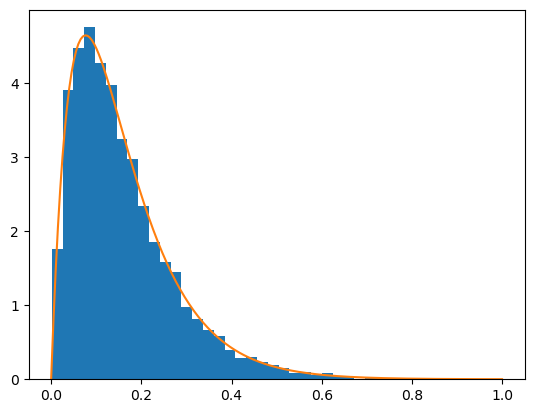

In [28]:
plt.hist(samples, density=True, bins=40);
plt.plot(np.linspace(0, 1, 200), pdf_2_parameters);

## Generate fluorescence intensity distributions

### Define rates

In [35]:
k_exc = 7e6
k_flu = 1e9
k_iscst = 1e6
k_iscts = 5e5
k_iso = 2e7
k_biso = 1e5

### Simulation

In [36]:
transitions = [['S0_S1', k_exc, "excitation", "EXC", False],  
               ['S1_S0', k_flu, "fluorescent emission", "FLU", True], 
               ['S1_T1', k_iscst, "intersystem crossing ST", "ISCST", False],   
               ['T1_S0', k_iscts, "intersystem crossing TS", "ISCTS", False],
               ['S1_Cis', k_iso, "isomerization", "ISO", False],
               ['Cis_S0', k_biso, "backisomerization", "BISO", False]]

system = fs.FluorophoreSystem(number_fluorophores=1, distances=1, transitions=transitions)
system.simulate(n_steps=int(1e7), seed=100)
system.process()
system.emitters(resample='1ms')

k_s1 = k_flu + k_iscst + k_iso
print(f'The rate of leaving S1 is {k_s1 :.3e}')

The rate of leaving S1 is 1.021e+09


### Extract sampling bounds

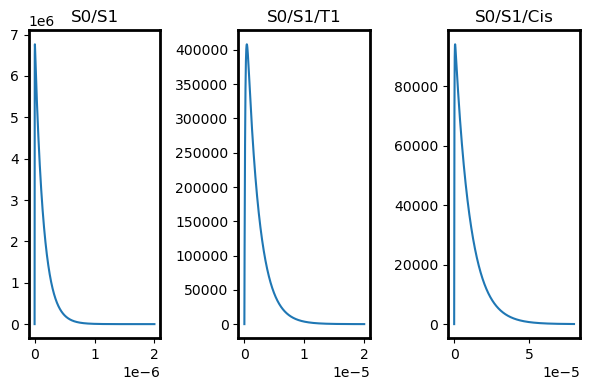

In [37]:
interval_1 = np.linspace(0, 2e-6, 10000)
pdf_s0_s1_s0 = \
    d.hypoexponential_distribution_two_parameters_pdf(k_exc, k_s1, interval_1)
interval_2 = np.linspace(0, 2e-5, 10000)
pdf_s0_s1_t1_s0 = \
    d.hypoexponential_distribution_three_parameters_pdf(k_exc, k_s1, k_iscts, interval_2)
interval_3 = np.linspace(0, 8e-5, 10000)                                                        
pdf_s0_s1_cis_s0 = \
    d.hypoexponential_distribution_three_parameters_pdf(k_exc, k_s1, k_biso, interval_3)

fig, ax = plt.subplots(ncols=3, nrows=1)
ax[0].plot(interval_1, pdf_s0_s1_s0)
ax[0].set_title('S0/S1')
ax[1].plot(interval_2, pdf_s0_s1_t1_s0)
ax[1].set_title('S0/S1/T1')
ax[2].plot(interval_3, pdf_s0_s1_cis_s0)
ax[2].set_title('S0/S1/Cis')
fig.tight_layout()

In [38]:
steps = int(1e7)
random_numbers = np.random.uniform(0, 1, steps)
events = np.zeros(steps)
time_steps = np.empty((steps, 1))

for i in range(steps):
    if random_numbers[i] < k_flu/k_s1:
        time_step = d.rejection_sampling(d.hypoexponential_distribution_two_parameters_pdf,
                                         x_min=0, x_max=2e-6, y_min=0, y_max=2e7, batch=10,
                                         size=1, parameters=[k_exc, k_s1])    
        time_steps[i] = time_step
        events[i] = 1  # extract fluorescence events
    elif random_numbers[i] < k_flu/k_s1 + k_iscst/k_s1:
        time_step = d.rejection_sampling(d.hypoexponential_distribution_three_parameters_pdf,
                                         x_min=0, x_max=2e-5, y_min=0, y_max=5e5, batch=10,
                                         size=1, parameters=[k_exc, k_s1, k_iscts])
        time_steps[i] = time_step
    else:
        time_step = d.rejection_sampling(d.hypoexponential_distribution_three_parameters_pdf,
                                         x_min=0, x_max=8e-5, y_min=0, y_max=1e5, batch=10,
                                         size=1, parameters=[k_exc, k_s1, k_biso])
        time_steps[i] = time_step

time_series = np.cumsum(time_steps)
mask = np.where(events==1)
events_at = time_series[mask]
events_at = np.insert(events_at, 0, 0)
time_deltas = pd.to_timedelta(events_at, unit="s")
events = np.ones(len(events_at))
events[0] = 0
series = pd.Series(events, index=time_deltas)
series = series.resample("1ms").sum()
time_deltas = series.index
in_seconds = time_deltas / np.timedelta64(1, "s")
series.index = in_seconds

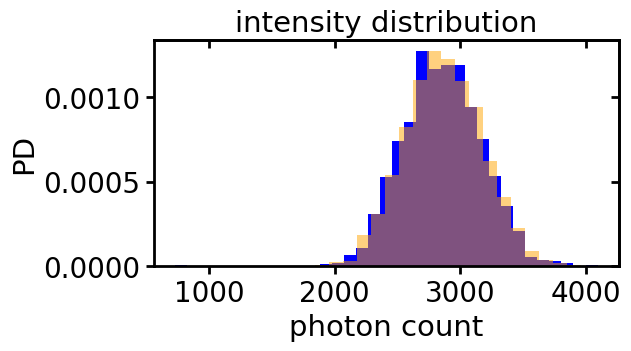

In [39]:
fig, ax = system.plot.emission_events(time_series=False, bins=35)
ax[0, 0].hist(series[series != 0], density=True, bins=20, alpha=0.5, color='orange');